24RB1074　半田悠人

## 課題1：$\lambda$ ($\alpha$)を変える

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import StandardScaler

Average difference (Train): -0.0000
Average difference (Test): -0.0000


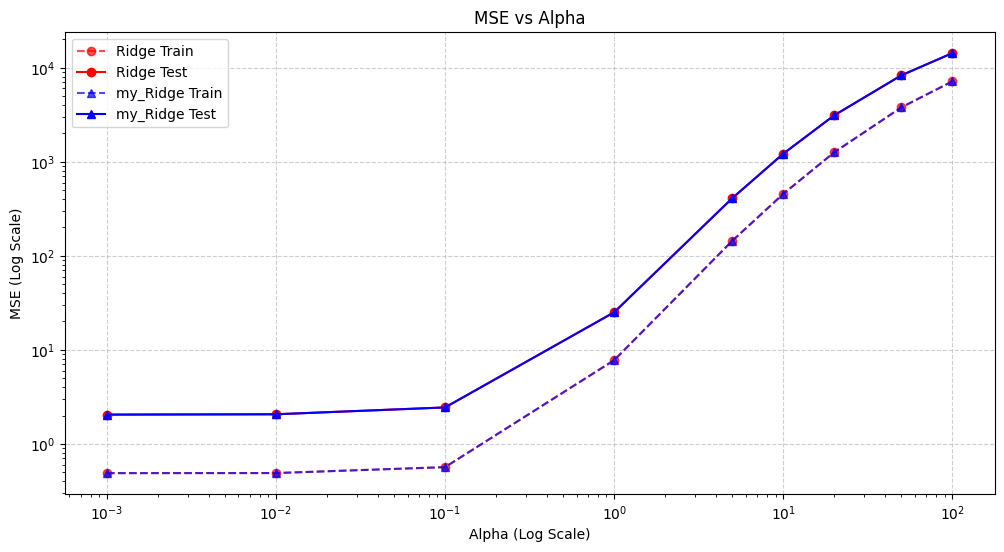

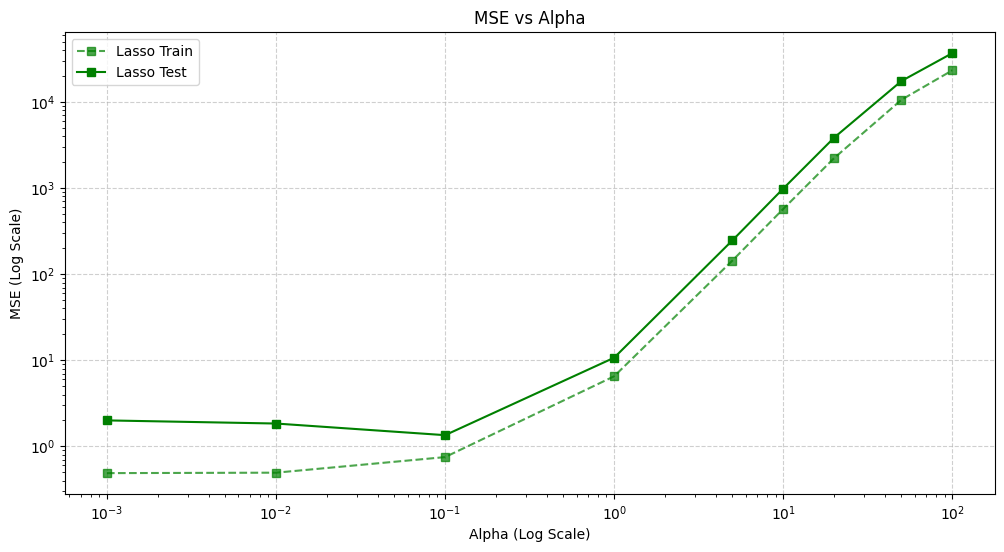

In [10]:
X, y = make_regression(n_samples=100, n_features=30, n_informative=5, noise=1, random_state=42)
#X, y = make_regression(n_samples = 100, n_features = 30, effective_rank = 5, noise = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 特徴量のスケーリング
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100]

# MSEを保存するリスト
my_Ridge_train_MSE = []
my_Ridge_test_MSE = []
Lasso_train_MSE = []
Lasso_test_MSE = []
Ridge_train_MSE = []
Ridge_test_MSE = []
ave_difference_train_MSE = []
ave_difference_test_MSE = []

for alpha in alphas:
    
    #my_Ridgeの実装
    w_hat_my_ridge = np.linalg.inv(X_train_scaled.T @ X_train_scaled + alpha * np.eye(X_train_scaled.shape[1])) @ X_train_scaled.T @ y_train
    intercept = np.mean(y_train)
    y_train_pred = (X_train_scaled @ w_hat_my_ridge) + intercept
    y_test_pred = (X_test_scaled @ w_hat_my_ridge) + intercept
    my_Ridge_train_MSE.append(np.mean((y_train_pred - y_train) ** 2))
    my_Ridge_test_MSE.append(np.mean((y_test_pred - y_test) ** 2))
    
    #Lassoの実装
    Lasso_model = Lasso(alpha=alpha, max_iter=10000)
    Lasso_model.fit(X_train_scaled, y_train)
    y_train_pred_lasso = Lasso_model.predict(X_train_scaled)
    y_test_pred_lasso = Lasso_model.predict(X_test_scaled)
    Lasso_train_MSE.append(np.mean((y_train_pred_lasso - y_train) ** 2))
    Lasso_test_MSE.append(np.mean((y_test_pred_lasso - y_test) ** 2))
    
    #Ridgeの実装
    Ridge_model = Ridge(alpha=alpha, max_iter=10000)
    Ridge_model.fit(X_train_scaled, y_train)
    y_train_pred_ridge = Ridge_model.predict(X_train_scaled)
    y_test_pred_ridge = Ridge_model.predict(X_test_scaled)
    Ridge_train_MSE.append(np.mean((y_train_pred_ridge - y_train) ** 2))
    Ridge_test_MSE.append(np.mean((y_test_pred_ridge - y_test) ** 2))
    
# 平均差の計算
ave_difference_train_MSE.append(np.mean([my_Ridge_train_MSE[i] - Ridge_train_MSE[i] for i in range(len(alphas))]))
ave_difference_test_MSE.append(np.mean([my_Ridge_test_MSE[i] - Ridge_test_MSE[i] for i in range(len(alphas))]))



ways = ['Ridge', 'Lasso']
for way in ways:
    plt.figure(figsize=(12, 6))

    if way == 'Ridge':
        plt.plot(alphas, Ridge_train_MSE, label=f'{way} Train', marker='o', linestyle='--', color='red', alpha=0.7)
        plt.plot(alphas, Ridge_test_MSE, label=f'{way} Test', marker='o', color='red')
        plt.plot(alphas, my_Ridge_train_MSE, label='my_Ridge Train', marker='^', linestyle='--', color='blue', alpha=0.7)
        plt.plot(alphas, my_Ridge_test_MSE, label='my_Ridge Test', marker='^', color='blue')
        
        print(f"Average difference (Train): {ave_difference_train_MSE[-1]:.4f}")
        print(f"Average difference (Test): {ave_difference_test_MSE[-1]:.4f}")
    elif way == 'Lasso':
        plt.plot(alphas, Lasso_train_MSE, label=f'{way} Train', marker='s', linestyle='--', color='green', alpha=0.7)
        plt.plot(alphas, Lasso_test_MSE, label=f'{way} Test', marker='s', color='green')



    # グラフの装飾
    plt.xscale('log') 
    plt.yscale('log')
    plt.xlabel('Alpha (Log Scale)')
    plt.ylabel('MSE (Log Scale)')
    plt.title('MSE vs Alpha')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.show()

## 説明

my_Ridgeの実装において、線形回帰モデルを $y = \mathbf{w}^\top \mathbf{x} + b$ とし、切片 $b$ を追加したいと考えた。そこで、コスト関数 $E(\mathbf{w}, b)$ を次のように定義しなおした。
$$E(\mathbf{w}, b) = \sum_{i=1}^{n} ( y_i - (\mathbf{w}^\top \mathbf{x}_i + b) )^2 + \lambda \|\mathbf{w}\|^2$$
ここで最適な切片 $b$ を求めるために、$E$ を $b$ で偏微分して $0$ と置く。
$$\frac{\partial E}{\partial b} = \sum_{i=1}^{n} 2 ( y_i - (\mathbf{w}^\top \mathbf{x}_i + b) ) \cdot (-1) = 0$$
$$\sum_{i=1}^{n} y_i - \sum_{i=1}^{n} \mathbf{w}^\top \mathbf{x}_i - \sum_{i=1}^{n} b = 0$$
また、今回は特徴量 $\mathbf{X}$ を事前に標準化しているため、$\sum_{i=1}^{n} \mathbf{x}_i = \mathbf{0}$ となる。
したがって、
$$\sum_{i=1}^{n} y_i - 0 - nb = 0$$
$$b = \frac{1}{n} \sum_{i=1}^{n} y_i$$
すなわち、最適な切片 $b$ は$y$ の平均値と一致する。これに基づいて、コード上では以下のように回帰を実装した。
```python
intercept = np.mean(y_train)

## 課題2：$L_2$と$L_1$の係数を比較

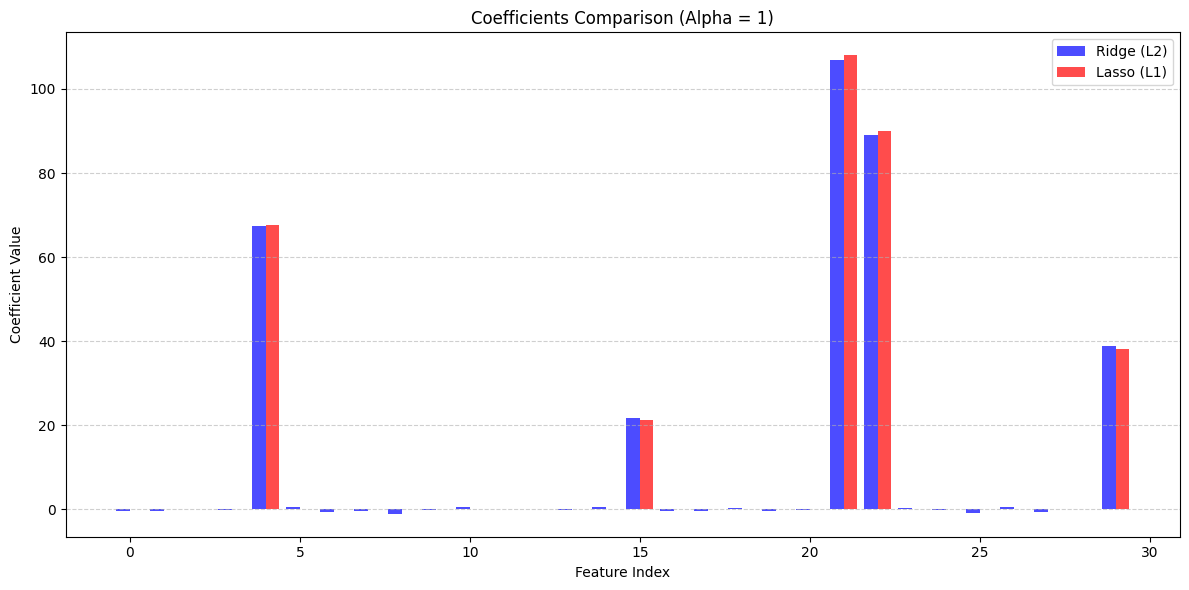

In [ ]:
plt.figure(figsize=(12, 6))

alpha = 1

lasso_coef = Lasso(alpha=alpha).fit(X_train_scaled, y_train).coef_
ridge_coef = Ridge(alpha=alpha).fit(X_train_scaled, y_train).coef_

x_positions = np.arange(X_train_scaled.shape[1])
bar_width = 0.4

plt.bar(x_positions - bar_width/2, ridge_coef, width=bar_width, label='Ridge (L2)', color='blue', alpha=0.7)
plt.bar(x_positions + bar_width/2, lasso_coef, width=bar_width, label='Lasso (L1)', color='red', alpha=0.7)

# グラフの装飾
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title(f'Coefficients Comparison (Alpha = {alpha})')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# レイアウトを調整して表示
plt.tight_layout()
plt.show()

## 観察と考察
### 課題１
* **手動実装との一致：** my_Ridgeとsklearn.linear_modelのRidgeの訓練誤差とテスト誤差がそれぞれ一致した。これは手動実装において、切片を追加し、正則化項から切片 $b$ を除外するというRidge回帰の数理モデルが正しく定式化されていることを示している。
* **正則化パラメータ $\alpha$ の影響：** $\alpha$ が $10^{-3}$ から $10^{-1}$ の範囲では、訓練誤差・テスト誤差ともに低く安定している。一方で、$\alpha$ が $10^{-1}$ を超えて大きくなると、両方の誤差が急激に増加している。これは正則化項が強すぎるためにアンダーフィッティングが起きていることを示している。したがって、このデータセットに対する最適な正則化の強さは $10^{-1}$ 以下の領域にあると推測できる。

### 課題２
* **有効特徴量の一致：** インデックス 4, 15, 21, 22, 29 の特徴量に対してのみ大きな係数が割り当てられており、RidgeとLassoの両モデルでその大きさはほぼ一致している。
* **Lassoのスパース性：** 重要でない特徴量の重みを完全にゼロにするというスパース性がグラフから確認できる。
* **Ridge回帰のパラメータ縮小：** 係数の2乗和にペナルティをかけるため、パラメータ全体を滑らかにゼロに近づけている。


## AI利用について
本演習課題の実施にあたり、以下の通りAIを活用した。

* 関数の調査・学習

    * 実現したい処理を行える関数の選定から、必要な引数、内部の処理内容、返り値についてAIに質問し、理解を深めた上で実装と確認を行った。
    * 調査した主な関数・メソッド: `scaler.fit_transform`, `scaler.transform`

* Ridgeの手動実装

    * 閉形式解で一意に定まるはずなのにsklearnのRidgeモデルの結果と合わなかったので、理由をコードとともに聞いた。